In [25]:
import sys
sys.path.append("../src")
from simulation_core.potential_force.norms import build_inv_norm_matrix
from simulation_core.potential_force.potentiel_force import build_potential_vector_force_torque_matrix
import numpy as np
from scipy.spatial.transform import Rotation

In [26]:
theta = 108 * 2*np.pi/360
r_oh = 0.5

In [ ]:
n = 100
Lx, Ly, Lz = 20, 20, 20
R = Rotation.random(n)
quats = R.as_quat().reshape(4*n)
v = np.concatenate([
    -Lx/2 + Lx * np.random.rand(n),
    -Ly/2 + Ly * np.random.rand(n),
    -Lz/2 + Lz * np.random.rand(n),
    np.zeros(3 * n),
    quats
])
q_o = 1.0
q_h = 1.0
nbr_list = np.ones((n,n))- np.eye(n)

In [28]:
import quaternion as qtn

In [29]:
M = build_inv_norm_matrix(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh)

In [30]:
np.array(M[1])

array([[[[ 0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ],
         [ 0.21190406, -0.97002286, -0.11896348,  0.        ,
           0.        ,  0.        ],
         [ 0.61841836, -0.36171944,  0.69765162,  0.        ,
           0.        ,  0.        ],
         ...,
         [-0.5323191 , -0.76136868,  0.37007311,  0.        ,
           0.        ,  0.        ],
         [-0.70770536,  0.28899186,  0.64469902,  0.        ,
           0.        ,  0.        ],
         [ 0.78125605,  0.51612813, -0.35107084,  0.        ,
           0.        ,  0.        ]],

        [[-0.21190406,  0.97002286,  0.11896348,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ],
         [ 0.07672268,  0.87597758,  0.47621099,  0.        ,
           0.        ,  0.        ],
         ...,
         [-0.8324127 , -0.03599151,  0.55298617,  0.        ,
           0.    

In [35]:
U, F = build_potential_vector_force_torque_matrix(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh, q_o, q_h)

In [39]:
F

array([[ 3.42391730e+00, -2.12148516e+00,  2.03543373e+00,
         1.07709150e+00,  1.34788748e+00,  7.19865070e-01],
       [-3.98937085e+00, -1.06764173e+00,  1.12799135e+00,
        -1.41955317e+00, -4.46345661e-01, -2.62882706e-01],
       [ 2.86306364e+00, -2.27325786e+00, -4.66195886e+00,
         2.48523715e+00,  3.26799574e+00,  7.17709794e-01],
       [ 6.86009222e+00,  7.00578506e+00,  1.04588357e+00,
        -8.66800134e-01,  6.32209567e-01, -3.39356164e+00],
       [ 1.16026384e+00, -1.34575000e+00, -1.77972584e+00,
         8.24675166e-01,  1.52883627e+00, -4.57987188e-02],
       [ 8.79015235e-01, -6.54868912e-02, -3.07939623e+00,
         1.61312953e-01, -1.06568014e-02, -1.25369238e+00],
       [-5.84444040e-01,  1.36137989e+00,  3.40844261e-01,
         7.59278635e-02, -8.08253420e-01,  2.34283148e-01],
       [ 1.65399986e+00, -2.38888218e-01, -3.09929222e-01,
        -7.30546732e-01, -4.06411800e-01, -6.99720195e-01],
       [ 6.68813417e+00, -1.52855261e+01,  9.534

In [28]:
import time
import matplotlib.pyplot as plt

In [ ]:
# list_n = np.array([50, 100, 250, 500, 750, 1000, 1500, 2000])
list_n = np.array(np.arange(200))
list_t = []

q_o = 1.0
q_h = 1.0
Lx, Ly, Lz = 20, 20, 20
theta = 108 * 2*np.pi/360
r_oh = 0.5

for n in list_n:
    R = Rotation.random(n)
    quats = R.as_quat().reshape(4*n)
    v = np.concatenate([
        -Lx/2 + Lx * np.random.rand(n),
        -Ly/2 + Ly * np.random.rand(n),
        -Lz/2 + Lz * np.random.rand(n),
        np.zeros(3 * n),
        quats
    ])
    nbr_list = np.ones((n,n))- np.eye(n)

    start = time.time()
    
    # U = build_potential_vector(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh, q_o, q_h)

    t = time.time() - start
    list_t.append(t)

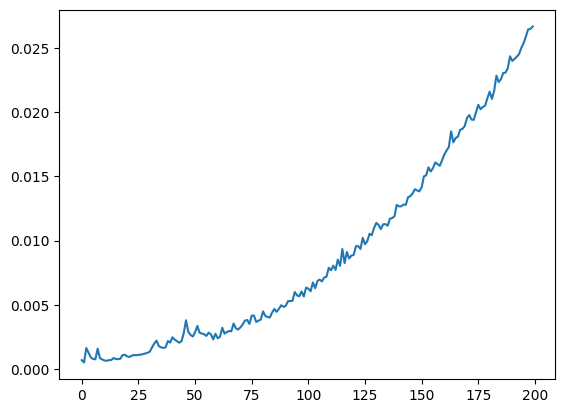

In [34]:
plt.plot(list_n, list_t)
plt.show()